In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append(f"{os.environ['HOME']}/Workbench/projects") # adapt to the actual location
sys.path.append(f"..")
import pandas as pd
import numpy as np
from toolbox.statistics.distributions.Gamma import Gamma
from toolbox.statistics.distributions.Normal import Normal
from toolbox.statistics.divergences import KL
from src.figures import (curve_fit,
                         discrete_fit)
from src.utils import config_loader

In [3]:
PATH_DF = "../data/dry_weight/pflanzen_incl_ratio.csv"
N_BINS = config_loader("../config/config.yaml")["N_BINS"]

In [4]:
df = pd.read_csv(PATH_DF)
df.head()

,Nr,Spross,Wurzel,Ratio
0,1,13.3,8.8,0.601810
1,2,27.1,9.9,0.732432
2,3,0.9,0.3,0.750000
3,4,10.0,5.5,0.645161
4,5,11.8,4.2,0.737500


#### Estimate Parameters

In [5]:
gamma = Gamma()

# sprout parameters
a_sprout = gamma.estimate_alpha(df["Spross"])
b_sprout = gamma.estimate_beta(df["Spross"])

# root parameters 
a_root = gamma.estimate_alpha(df["Wurzel"])
b_root = gamma.estimate_beta(df["Wurzel"])

# export as .csv
rows = ["sprout_a", "sprout_b", "root_a", "root_b"]
columns = ["values_estimate"]
df_gamma = pd.DataFrame(index=rows, columns=columns, data=[a_sprout, b_sprout, a_root, b_root])
df_gamma.to_csv("../data/estimated_parameters/gamma_parameters.csv")

In [18]:
normal = Normal()

# sprout parameters
mean_sprout = normal.estimate_mean(df["Spross"])
std_sprout = normal.estimate_std(df["Spross"])

# root parameters 
mean_root = normal.estimate_mean(df["Wurzel"])
std_root = normal.estimate_std(df["Wurzel"])

# export as .csv
rows = ["sprout_mean", "sprout_std", "root_mean", "root_std"]
columns = ["values_estimate"]
df_gamma = pd.DataFrame(index=rows, columns=columns, data=[mean_sprout, std_sprout, mean_root, std_root])
df_gamma.to_csv("../data/estimated_parameters/normal_parameters.csv")

#### Inspect Fit

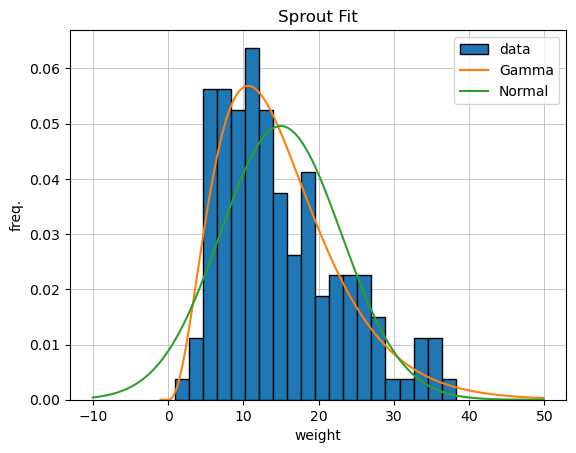

In [7]:
fig = curve_fit(df, 
                "Spross",
                "Sprout Fit",
                curves = [gamma.PDF(alpha=a_sprout, beta=b_sprout, x_min=-1, x_max=50),
                          normal.PDF(mean=mean_sprout, var=std_sprout, x_min=-10, x_max=50)],
                labels = ["Gamma", "Normal"])
fig.savefig("../reports/figures/inspect_fit_sprout.png", bbox_inches="tight")

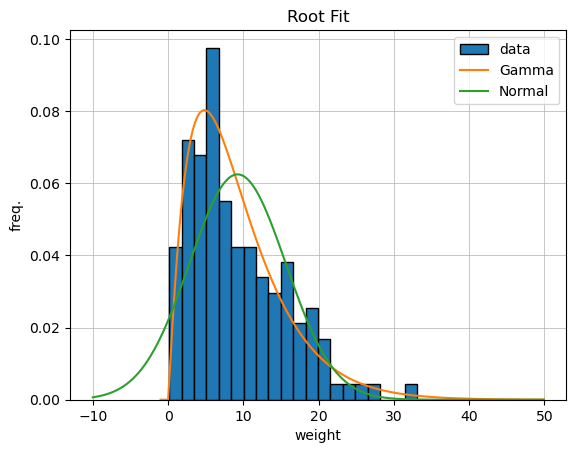

In [8]:
fig = curve_fit(df, 
                "Wurzel",
                "Root Fit",
                curves = [gamma.PDF(alpha=a_root, beta=b_root, x_min=-1, x_max=50),
                          normal.PDF(mean=mean_root, var=std_root, x_min=-10, x_max=50)],
                labels = ["Gamma", "Normal"])
fig.savefig("../reports/figures/inspect_fit_root.png", bbox_inches="tight")

#### Discrete Fit - Sprout

In [9]:
x, y_gamma_sprout = gamma.PMF(a_sprout, b_sprout, bins = N_BINS, 
                       xmin=df.Spross.min(), xmax=df.Spross.max())
x, y_normal_sprout = normal.PMF(mean_sprout, std_sprout, bins = N_BINS, 
                        xmin=df.Spross.min(), xmax=df.Spross.max())

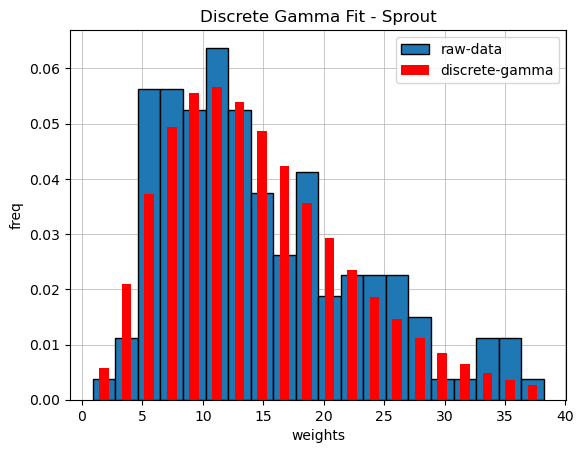

In [10]:
fig = discrete_fit(df = df, 
             column = "Spross", 
             title = "Discrete Gamma Fit - Sprout", 
             labels = ["raw-data", "discrete-gamma"], 
             data = [x, y_gamma_sprout])
fig.savefig("../reports/figures/inspect_discrete_gamma_fit_sprout.png", bbox_inches="tight")

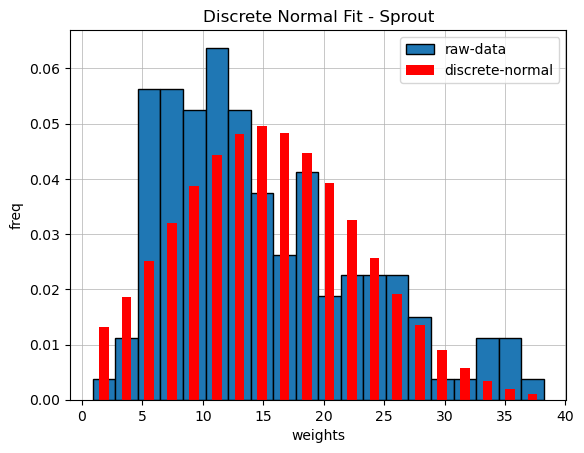

In [11]:
fig = discrete_fit(df = df, 
             column = "Spross", 
             title = "Discrete Normal Fit - Sprout", 
             labels = ["raw-data", "discrete-normal"], 
             data = [x, y_normal_sprout])
fig.savefig("../reports/figures/inspect_discrete_normal_fit_sprout.png", bbox_inches="tight")

#### Discrete Fit - Root 

In [12]:
x, y_gamma_root = gamma.PMF(a_root, b_root, bins = N_BINS, 
                       xmin=df.Wurzel.min(), xmax=df.Wurzel.max())
x, y_normal_root = normal.PMF(mean_root, std_root, bins = N_BINS, 
                        xmin=df.Wurzel.min(), xmax=df.Wurzel.max())

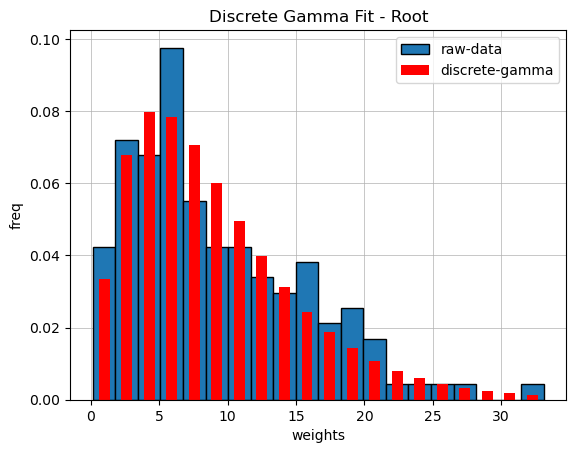

In [13]:
fig = discrete_fit(df = df, 
             column = "Wurzel", 
             title = "Discrete Gamma Fit - Root", 
             labels = ["raw-data", "discrete-gamma"], 
             data = [x, y_gamma_root])
fig.savefig("../reports/figures/inspect_discrete_gamma_fit_root.png", bbox_inches="tight")

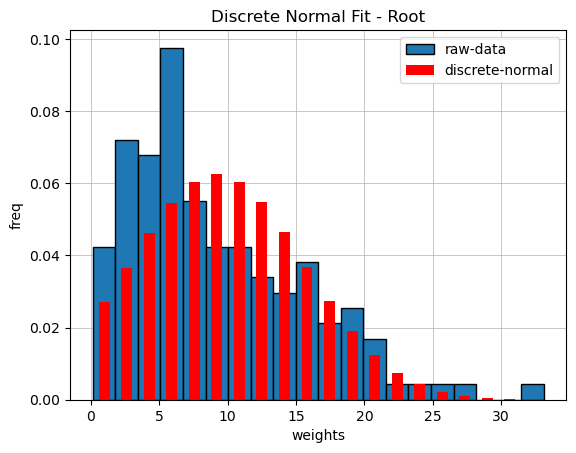

In [14]:
fig = discrete_fit(df = df, 
             column = "Wurzel", 
             title = "Discrete Normal Fit - Root", 
             labels = ["raw-data", "discrete-normal"], 
             data = [x, y_normal_root])
fig.savefig("../reports/figures/inspect_discrete_normal_fit_root.png", bbox_inches="tight")

#### Futher Evaluate with $D_{KL}$ (Kullback-Leibler-Divergence)  

In [15]:
n_sprout, _ = np.histogram(df["Spross"], bins=N_BINS, density=True)
n_root, _ = np.histogram(df["Wurzel"], bins=N_BINS, density=True)

In [16]:
kl_sprout_gamma = KL(n_sprout, y_gamma_sprout)
kl_sprout_normal = KL(n_sprout, y_normal_sprout)
kl_root_gamma = KL(n_root, y_gamma_root)
kl_root_normal = KL(n_root, y_normal_root)

In [17]:
rows = ["kl_sprout_gamma", "kl_sprout_normal", "kl_root_gamma", "kl_root_normal"]
columns = ["values"]
data = [kl_sprout_gamma, kl_sprout_normal, kl_root_gamma, kl_root_normal]
df_kl = pd.DataFrame(data=data, index=rows, columns=columns)
df_kl.to_csv("../data/divergences/kl_divergences_marginal_distribution.csv")